In [23]:
import numpy as np
import os
from pathlib import Path
from plyfile import PlyData
import sys
import warnings
import pickle
import time
import gc

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
from sklearn.preprocessing import StandardScaler

import wandb
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

In [24]:
FILE_PATH = os.path.join(os.getcwd(), "..","..","..","data", "processed", "Watchai01.ply")

In [25]:
path = os.getcwd()

while path != os.path.dirname(path):
    if os.path.exists(os.path.join(path, 'src')):
        if path not in sys.path:
            sys.path.insert(0, path)
        print(f"Found Project Root at: {path}")
        break
    path = os.path.dirname(path)

Found Project Root at: c:\Users\babxk\Documents\GitHub\archaeological-site


In [28]:
from src.features.data_loader import ArchaeologicalLoader
from src.features.feature import HeritagePointCloudDataset
from src.models.pointnetplus import PointNet2SemSeg
from src.metric.metrics import Evaluator
from src.metric.visualize import Visualizer

In [5]:
dataset = HeritagePointCloudDataset(FILE_PATH ,block_size=(0.5, 0.5))

โหลด Label จาก 'scalar_class' สำเร็จ! (พบ 5 คลาส)


In [6]:
loader_factory = ArchaeologicalLoader(dataset)

batch_size > 1 อาจทำให้เกิด Error ได้ ระบบจะปรับเป็น 1 ให้ชั่วคราว


In [7]:
train_loader, test_loader = loader_factory.get_loaders()

In [8]:
def train(
    model,
    train_loader,
    test_loader=None,
    num_epochs=100,
    lr=0.001,
    save_path="best_pointnet2.pth", 
):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    weights = torch.tensor(
        [
            0.25,  
            5.0,  
            8.0,  
            12.0, 
            1.4,
        ],
        dtype=torch.float32,
    ).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    best_metric_acc = 0.0
    visualizer = Visualizer() 

    for epoch in range(num_epochs):
        start_time = time.time()

        # ------------------- โหมด Train -------------------
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for points, labels in train_loader:
            points, labels = points.to(device), labels.to(device, dtype=torch.long)
           

            optimizer.zero_grad()
            
            outputs = model(points)

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.numel()
            train_correct += (predicted == labels).sum().item()

        scheduler.step()
        train_acc = 100.0 * train_correct / train_total
        avg_train_loss = train_loss / len(train_loader)

        # ------------------- โหมด Test -------------------
        test_acc = None
        avg_test_loss = None

        if test_loader is not None:
            model.eval()
            test_loss = 0.0
            test_correct = 0
            test_total = 0

            with torch.no_grad():
                for points, labels in test_loader:
                    points, labels = points.to(device), labels.to(device, dtype=torch.long)
                    
                    outputs = model(points)

                    loss = criterion(outputs, labels)

                    test_loss += loss.item()
                    _, predicted = torch.max(outputs, 1)
                    test_total += labels.numel()
                    test_correct += (predicted == labels).sum().item()

            test_acc = 100.0 * test_correct / test_total
            avg_test_loss = test_loss / len(test_loader)

        visualizer.update(
            epoch=epoch + 1,
            train_loss=avg_train_loss,
            test_loss=avg_test_loss,
            train_acc=train_acc,
            test_acc=test_acc,
        )

        epoch_time = time.time() - start_time
        print(f"Epoch [{epoch+1:03d}/{num_epochs}] | Time: {epoch_time:.1f}s")
        print(f"   Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")

        if test_loader is not None:
            print(f"   Test Loss:  {avg_test_loss:.4f} | Test Acc:  {test_acc:.2f}%")
            if test_acc > best_metric_acc:
                best_metric_acc = test_acc
                torch.save(model.state_dict(), save_path)
                print(f" Best: {best_metric_acc:.2f}% (บันทึกโมเดลแล้ว)")
        else:
            if train_acc > best_metric_acc:
                best_metric_acc = train_acc
                torch.save(model.state_dict(), save_path)
                print(f" Best: {best_metric_acc:.2f}% (บันทึกโมเดลแล้ว)")

        print("-" * 50)

    visualizer.plot(save_path="PointNet++_training_curves.png")

    return model

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
model = PointNet2SemSeg(num_classes=5, additional_features=10).to(device)

In [11]:
torch.cuda.empty_cache()
gc.collect()
print(f"VRAM ว่างแล้ว: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")

VRAM ว่างแล้ว: 6.01 MB


Epoch [001/100] | Time: 137.5s
   Train Loss: 1.2865 | Train Acc: 58.78%
 Best: 58.78% (บันทึกโมเดลแล้ว)
--------------------------------------------------
Epoch [002/100] | Time: 137.4s
   Train Loss: 1.1960 | Train Acc: 61.82%
 Best: 61.82% (บันทึกโมเดลแล้ว)
--------------------------------------------------
Epoch [003/100] | Time: 128.5s
   Train Loss: 1.1497 | Train Acc: 64.60%
 Best: 64.60% (บันทึกโมเดลแล้ว)
--------------------------------------------------
Epoch [004/100] | Time: 129.7s
   Train Loss: 1.1271 | Train Acc: 64.90%
 Best: 64.90% (บันทึกโมเดลแล้ว)
--------------------------------------------------
Epoch [005/100] | Time: 130.9s
   Train Loss: 1.1141 | Train Acc: 66.88%
 Best: 66.88% (บันทึกโมเดลแล้ว)
--------------------------------------------------
Epoch [006/100] | Time: 127.5s
   Train Loss: 1.0795 | Train Acc: 67.36%
 Best: 67.36% (บันทึกโมเดลแล้ว)
--------------------------------------------------
Epoch [007/100] | Time: 125.1s
   Train Loss: 1.0613 | Train Acc

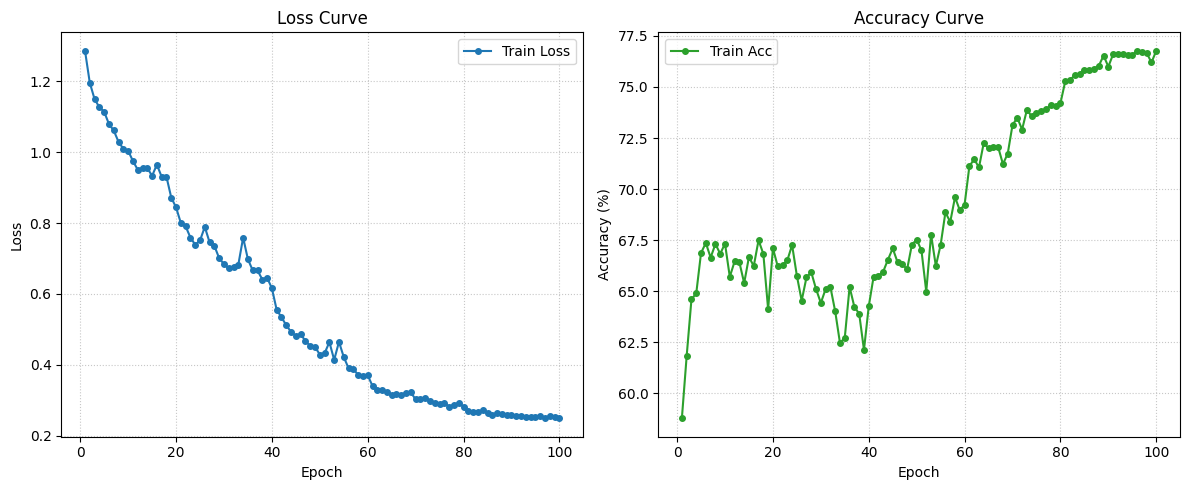

In [12]:
trained_model = train(
    model=model,
    train_loader=train_loader,
    num_epochs=100,
    lr=0.001
)

In [13]:
class_names = ['Intact_Brick', 'Material_Spalling', 'Moderate_Crack', 'Severe_Crack','Vegetation']

In [29]:
class PlusEvaluator:
    def __init__(self, model, test_loader, num_classes=5, class_names=None):
        """
        Args:
            model: โมเดล PointNet++ ที่ผ่านการเทรนมาแล้ว
            test_loader: DataLoader สำหรับชุด Test
            num_classes: จำนวน Class ทั้งหมด (Default: 5)
            class_names: List ชื่อของแต่ละ Class เพื่อให้พิมพ์ผลลัพธ์อ่านง่ายขึ้น
        """
        self.model = model
        self.test_loader = test_loader
        self.num_classes = num_classes
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = self.model.to(self.device)
        
        if class_names is None:
            self.class_names = [f"Class {i}" for i in range(num_classes)]
        else:
            self.class_names = class_names
            
    def evaluate(self):
        self.model.eval() 
        
        total_correct = 0
        total_seen = 0
        
        tps = torch.zeros(self.num_classes).to(self.device)
        fps = torch.zeros(self.num_classes).to(self.device)
        fns = torch.zeros(self.num_classes).to(self.device)
        
        with torch.no_grad(): 
            for points, labels in self.test_loader:
                points = points.to(self.device)
                labels = labels.to(self.device, dtype=torch.long)
                
                
                outputs = self.model(points)
                
                preds = torch.max(outputs, 1)[1] # Shape: [Batch, Num_Points]
                
                total_correct += (preds == labels).sum().item()
                total_seen += labels.numel()
                
                for c in range(self.num_classes):
                    pred_c = (preds == c)
                    label_c = (labels == c)
                    
                    tps[c] += (pred_c & label_c).sum()
                    fps[c] += (pred_c & ~label_c).sum()
                    fns[c] += (~pred_c & label_c).sum()
        
        overall_accuracy = (total_correct / total_seen) * 100
        
        ious = tps / (tps + fps + fns + 1e-6)
        ious = ious.cpu().numpy() * 100 
        
        mean_iou = np.mean(ious)

        self._print_report(overall_accuracy, ious, mean_iou)
        
        return overall_accuracy, mean_iou, ious

    def _print_report(self, overall_accuracy, ious, mean_iou):
        print("="*50)
        print("Evaluation Report".center(50))
        print("="*50)
        print(f"Overall Accuracy: {overall_accuracy:.2f}%")
        print(f"Mean IoU :        {mean_iou:.2f}%")
        print("-" * 50)
        print("Class-wise IoU:")
        for i, name in enumerate(self.class_names):
            print(f"   - {name:<15}: {ious[i]:.2f}%")
        print("="*50)

In [30]:
evaluator = PlusEvaluator(
    model=trained_model, 
    test_loader=test_loader, 
    num_classes=5, 
    class_names=class_names
)

In [31]:
oa, miou, class_ious = evaluator.evaluate()

                Evaluation Report                 
Overall Accuracy: 70.27%
Mean IoU :        23.43%
--------------------------------------------------
Class-wise IoU:
   - Intact_Brick   : 68.26%
   - Material_Spalling: 13.55%
   - Moderate_Crack : 0.55%
   - Severe_Crack   : 2.94%
   - Vegetation     : 31.86%
